## 1. Load features and inspect per bearing

This cell loads time domain and spectral features for the 3rd test dataset.
One row is one measurement in time.
Each table shows the first 5 rows for one bearing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/3rd_test/'
print(f"Loading raw files from {DATA_DIR}...", flush=True)
df = extract_features(DATA_DIR)
print(f"Extraction done: {df.shape[0]} rows x {df.shape[1]} columns", flush=True)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

Loading raw files from data/raw/3rd_test/...


Extraction done: 6324 rows x 36 columns


=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std,Bearing_1_SpecCentroid,Bearing_1_HighFreqRatio,Bearing_1_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.079768,1.292720,7.133162,0.569,0.030877,0.079629,2900.483503,0.113801,0.063335
2004-03-04 09:32:46,0.078678,1.157037,6.240622,0.491,-0.013807,0.078512,3077.181630,0.144776,0.084005
2004-03-04 09:42:46,0.079815,0.890123,6.452419,0.515,0.033420,0.079784,3070.335416,0.138980,0.089831
2004-03-04 09:52:46,0.081082,1.181861,6.807885,0.552,-0.027040,0.081042,2996.691981,0.118711,0.059764
2004-03-04 10:02:46,0.079165,0.585798,4.812731,0.381,-0.017775,0.079124,3001.163020,0.126731,0.073100


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std,Bearing_2_SpecCentroid,Bearing_2_HighFreqRatio,Bearing_2_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.096720,0.776451,5.448737,0.527,0.152047,0.096641,3799.928740,0.326253,0.068290
2004-03-04 09:32:46,0.092008,0.701936,5.836461,0.537,0.146246,0.091866,3818.949318,0.333898,0.103519
2004-03-04 09:42:46,0.093430,0.936667,6.379091,0.596,0.171805,0.093403,3804.575379,0.338337,0.103559
2004-03-04 09:52:46,0.092803,0.379354,5.527828,0.513,0.166074,0.092796,3675.555137,0.319033,0.072276
2004-03-04 10:02:46,0.092829,0.504029,6.054119,0.562,0.145980,0.092826,3697.280415,0.324487,0.086263


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std,Bearing_3_SpecCentroid,Bearing_3_HighFreqRatio,Bearing_3_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.066390,0.592253,5.437565,0.361,0.083455,0.066190,3605.895118,0.327567,0.035414
2004-03-04 09:32:46,0.066285,0.360079,4.450449,0.295,0.011829,0.065984,3674.816798,0.344769,0.043557
2004-03-04 09:42:46,0.069186,0.214038,4.133782,0.286,0.049060,0.069174,3470.286314,0.319801,0.060433
2004-03-04 09:52:46,0.068637,0.299358,5.084751,0.349,0.002209,0.068599,3517.982942,0.318080,0.039290
2004-03-04 10:02:46,0.067469,0.396086,5.750781,0.388,0.031886,0.067447,3543.133855,0.329432,0.038203


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std,Bearing_4_SpecCentroid,Bearing_4_HighFreqRatio,Bearing_4_SpecPeak
Time,,,,,,,,,
2004-03-04 09:27:46,0.055493,0.560054,5.460190,0.303,0.038848,0.055323,3021.688928,0.103884,0.027727
2004-03-04 09:32:46,0.053351,0.356036,4.667234,0.249,0.013905,0.052925,2988.231816,0.121953,0.042174
2004-03-04 09:42:46,0.052703,0.478295,5.274828,0.278,0.034238,0.052606,3002.865429,0.124729,0.047238
2004-03-04 09:52:46,0.054844,0.342058,5.470035,0.300,0.007404,0.054669,2990.955046,0.123240,0.031650
2004-03-04 10:02:46,0.053914,0.261778,4.581358,0.247,0.023475,0.053804,2931.272902,0.123450,0.037605


## 2. All features over the full timeline

One subplot per feature, all 4 bearings in each.
Flat and low means healthy. A sharp rise means the fault starts.

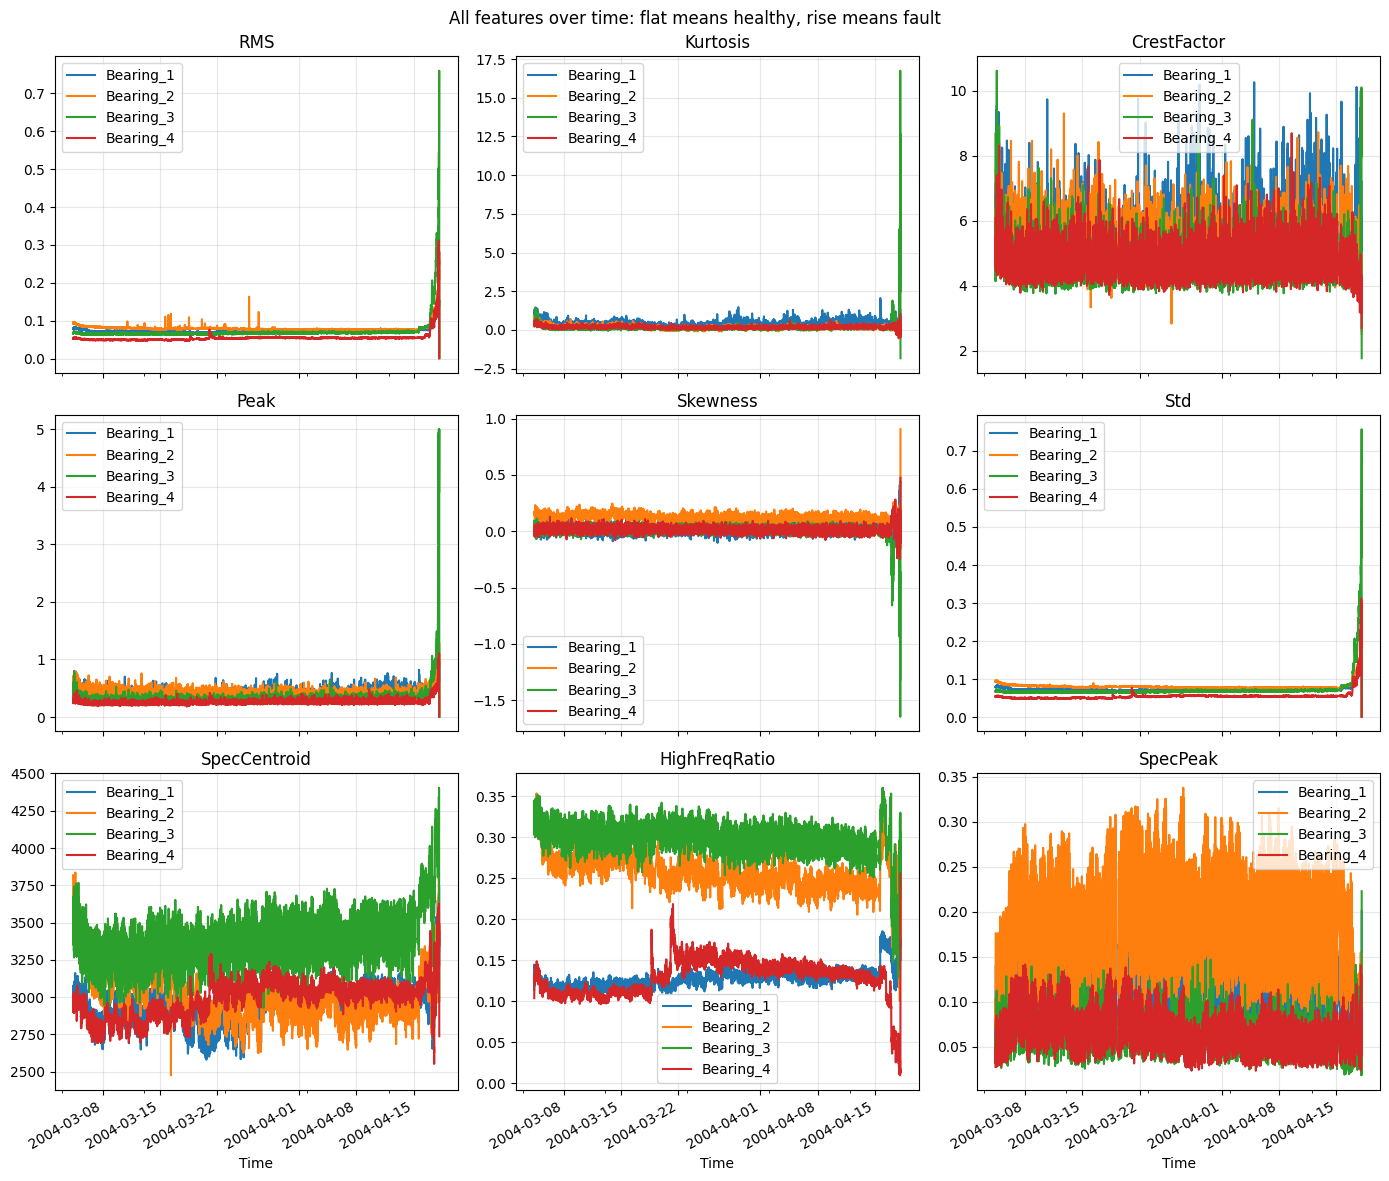

In [2]:
features = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
            'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True)
for ax, feat in zip(axes.flat, features):
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    renamed = {c: c.replace('_' + feat, '') for c in cols}
    df[cols].rename(columns=renamed).plot(ax=ax)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
plt.suptitle('All features over time: flat means healthy, rise means fault')
plt.tight_layout()
plt.show()

## 3. Fault localization: which bearing fails

Compare late against early values per bearing and per feature, no boundary needed.
A healthy channel stays near growth 1. The failed bearing grows on several
independent features at once. Skewness is left out, its healthy baseline sits
near zero so ratios explode.

In [3]:
from src.evaluation import identify_faulty_bearing

result = identify_faulty_bearing(df)
display(result['summary'])
print(f"Faulty bearing: {result['faulty_bearing']}")

,rms_growth,kurtosis_growth,crest_factor_growth,peak_growth,std_growth
bearing,,,,,
Bearing_1,1.43,0.46,0.88,1.27,1.43
Bearing_2,1.65,0.03,0.76,1.25,1.66
Bearing_3,4.01,2.98,0.92,4.03,4.01
Bearing_4,2.61,0.22,0.77,1.97,2.62


Faulty bearing: Bearing_3


### Reading the table above

Every number is a quotient, late mean divided by early mean.
Near 1 means late looks like early, no change. Far from 1 means change.
Rows do not share one reading direction, each row has its own logic.
The code prints the bearing with the highest average across the growing
features. Documentation says outer race fault on Bearing 3, which serves
as confirmation only if the data agrees.

Bearing 4 deserves a note: second highest RMS growth (2.61x) but kurtosis
growth of only 0.22, below 1. Loud but smooth means shaken, not faulty: it
vibrates because Bearing 3 shakes the shared shaft, without impacts of its
own. A true fault brings both noise and spikiness, as Bearing 3 shows
(4.01x RMS with 2.98x kurtosis).

## 4. Faulty bearing in detail

The previous section identified the faulty bearing, details below use it automatically.
Each feature has its own plot because features use different scales.
Look at which feature reacts first when the fault starts.

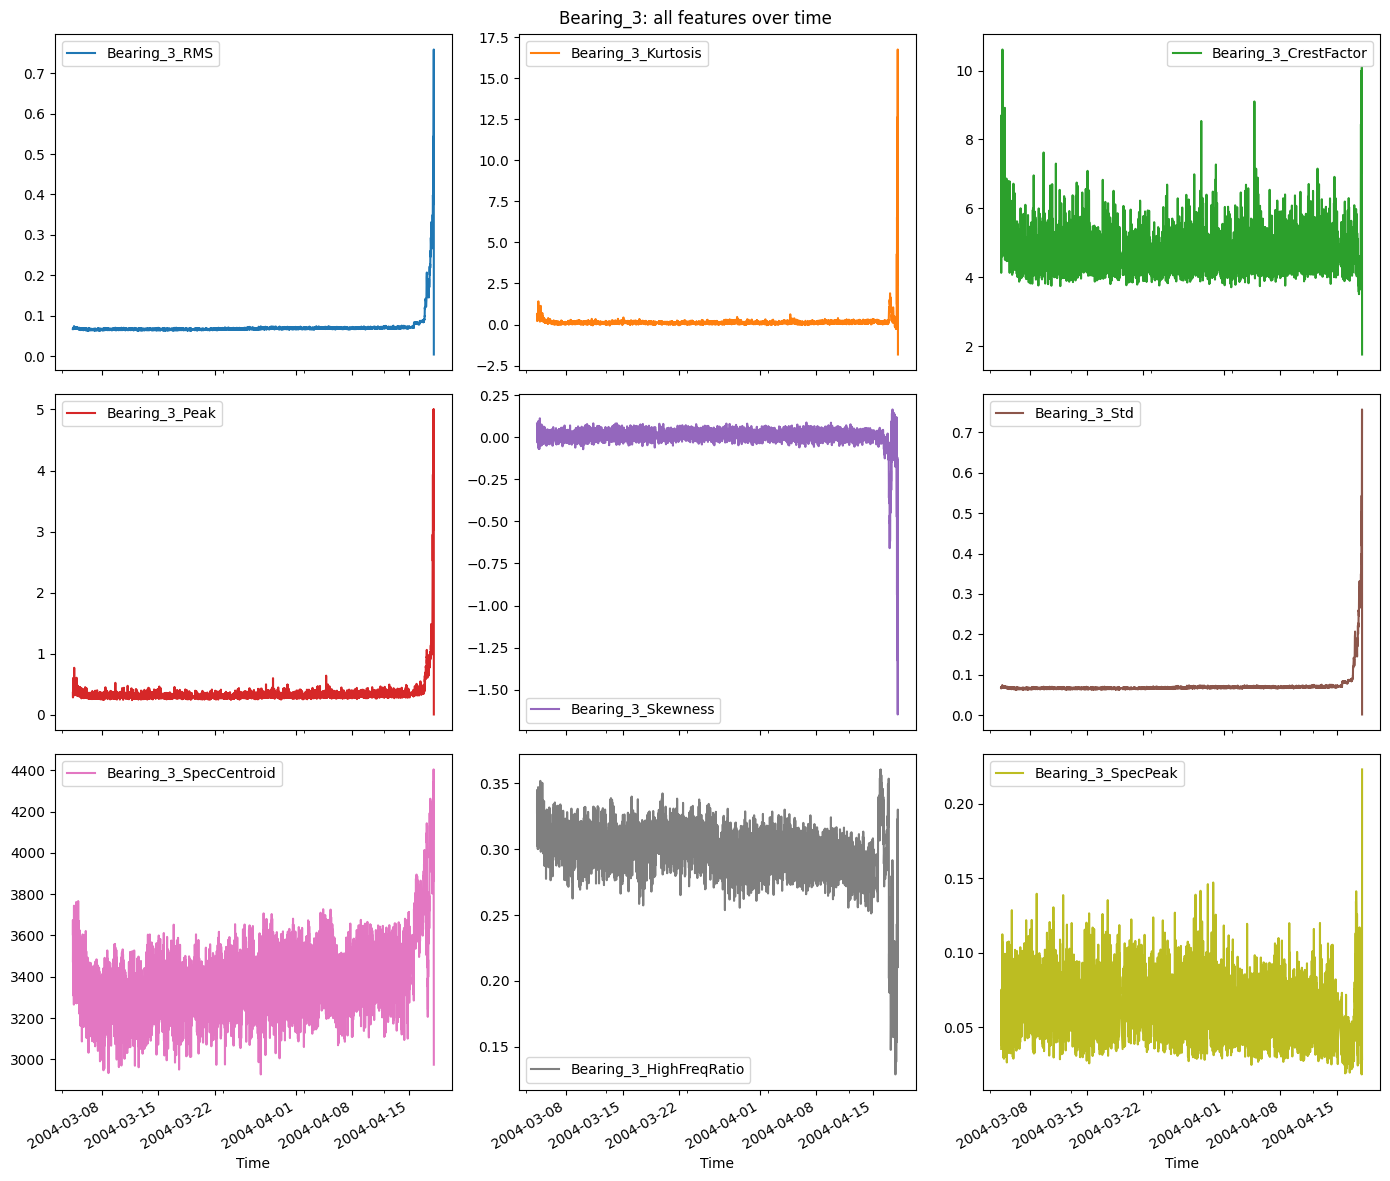

In [4]:
FAULTY = result['faulty_bearing']
faulty_cols = [c for c in df.columns if c.startswith(FAULTY + '_')]
n = len(faulty_cols)
nrows = (n + 2) // 3
df[faulty_cols].plot(figsize=(14, 4 * nrows), subplots=True, layout=(nrows, 3))
plt.suptitle(f"{FAULTY}: all features over time")
plt.tight_layout()
plt.show()

## 5. Compare healthy boundary candidates

Bearing 3 RMS sits near 0.066 through March and rises in April, so candidates
span mid March into mid April. Six features vote: RMS, Kurtosis, Peak and the three spectral features. Std is excluded as a proven RMS duplicate, CrestFactor and Skewness for documented reasons.
Same rule as before: widest boundary with stable threshold, alarm and FPR wins.

In [5]:
from src.evaluation import compare_boundaries

candidates = [
    pd.Timestamp('2004-03-15'),
    pd.Timestamp('2004-03-18'),
    pd.Timestamp('2004-03-22'),
    pd.Timestamp('2004-03-25'),
    pd.Timestamp('2004-03-28'),
    pd.Timestamp('2004-03-31'),
    pd.Timestamp('2004-04-03'),
    pd.Timestamp('2004-04-06'),
    pd.Timestamp('2004-04-09'),
    pd.Timestamp('2004-04-12'),
    pd.Timestamp('2004-04-14'),
]
for feat in ['Bearing_3_RMS', 'Bearing_3_Kurtosis', 'Bearing_3_Peak',
             'Bearing_3_SpecCentroid', 'Bearing_3_HighFreqRatio', 'Bearing_3_SpecPeak']:
    print(f"=== {feat} ===")
    display(compare_boundaries(df[feat], candidates))

=== Bearing_3_RMS ===


,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-03-15,1528,0.070927,2004-04-15 18:22:55,0.011780
1,2004-03-18,1935,0.070791,2004-04-15 18:22:55,0.009302
2,2004-03-22,2467,0.070537,2004-04-15 18:22:55,0.008107
3,2004-03-25,2899,0.070692,2004-04-15 18:22:55,0.006554
4,2004-03-28,3331,0.071159,2004-04-15 18:22:55,0.007805
5,2004-03-31,3763,0.071898,2004-04-15 18:22:55,0.005581
6,2004-04-03,4195,0.072252,2004-04-15 18:22:55,0.004052
7,2004-04-06,4621,0.072784,2004-04-15 18:22:55,0.003246
8,2004-04-09,5053,0.072978,2004-04-15 18:22:55,0.002771
9,2004-04-12,5485,0.073457,2004-04-15 18:22:55,0.001276


=== Bearing_3_Kurtosis ===


,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-03-15,1528,0.472997,2004-04-17 02:52:55,0.021597
1,2004-03-18,1935,0.443890,2004-04-17 02:52:55,0.019638
2,2004-03-22,2467,0.412447,2004-04-17 02:52:55,0.020268
3,2004-03-25,2899,0.393903,2004-04-17 02:42:55,0.019317
4,2004-03-28,3331,0.380754,2004-04-17 02:42:55,0.017712
5,2004-03-31,3763,0.375542,2004-04-17 02:42:55,0.016476
6,2004-04-03,4195,0.366579,2004-04-17 02:42:55,0.015971
7,2004-04-06,4621,0.363478,2004-04-17 02:42:55,0.015581
8,2004-04-09,5053,0.356701,2004-04-17 02:42:55,0.014645
9,2004-04-12,5485,0.354768,2004-04-17 02:42:55,0.013856


=== Bearing_3_Peak ===


...

,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-03-15,1528,3717.742222,2004-04-16 23:22:55,0.002618
1,2004-03-18,1935,3718.481111,2004-04-16 23:22:55,0.002067
2,2004-03-22,2467,3704.296759,2004-04-16 23:22:55,0.002432
3,2004-03-25,2899,3705.415466,2004-04-16 23:22:55,0.001725
4,2004-03-28,3331,3711.136771,2004-04-16 23:22:55,0.001501
5,2004-03-31,3763,3730.163792,2004-04-16 23:32:55,0.000797
6,2004-04-03,4195,3739.488793,2004-04-17 00:02:55,0.000715
7,2004-04-06,4621,3753.865962,2004-04-17 00:02:55,0.000433
8,2004-04-09,5053,3753.082224,2004-04-17 00:02:55,0.000396
9,2004-04-12,5485,3758.415503,2004-04-17 00:02:55,0.000365


=== Bearing_3_HighFreqRatio ===


,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-03-15,1528,0.347450,None,0.001309
1,2004-03-18,1935,0.347401,None,0.001034
2,2004-03-22,2467,0.346943,None,0.000811
3,2004-03-25,2899,0.346288,None,0.001035
4,2004-03-28,3331,0.345984,None,0.000901
5,2004-03-31,3763,0.345923,None,0.000797
6,2004-04-03,4195,0.345473,None,0.000715
7,2004-04-06,4621,0.344714,None,0.000866
8,2004-04-09,5053,0.343929,None,0.001385
9,2004-04-12,5485,0.343545,None,0.001276


=== Bearing_3_SpecPeak ===


,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-03-15,1528,0.124011,None,0.002618
1,2004-03-18,1935,0.123200,None,0.003618
2,2004-03-22,2467,0.125185,None,0.002837
3,2004-03-25,2899,0.124557,None,0.002415
4,2004-03-28,3331,0.123734,None,0.002402
5,2004-03-31,3763,0.123301,None,0.003720
6,2004-04-03,4195,0.122262,None,0.003814
7,2004-04-06,4621,0.121130,None,0.004112
8,2004-04-09,5053,0.120325,None,0.004156
9,2004-04-12,5485,0.119377,None,0.004558


### Reading the boundary vote

RMS leads with 15.04 on every candidate. Kurtosis and Peak follow two days later on 17.04, late but
stable everywhere. SpecCentroid confirms on 16-17.04,
stable across all boundaries. HighFreqRatio and SpecPeak never confirm alone: too spiky
to hold 20 in a row, yet they contribute inside the joint setup.
FPR stays low on all six features. Boundary 12.04 is the widest candidate on which all six votes stand still: every alarm matches all earlier candidates, while 14.04 shows the first crack (RMS slips to 18:32). It also carries the most training data (5,485 samples) for free.

## 6. Decision: chosen healthy boundary

We choose 2004-04-12 (5,485 healthy samples) - the widest boundary
on which all six votes stand still.

In [2]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-04-12')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-04-12 00:00:00


## 7. Split into healthy / full dataset

Using the boundary chosen above. We further split the healthy period into
a training part (fits the model/scaler) and a validation part (sets the
threshold).

In [3]:
from src.preprocessing import split_healthy, scale_features, split_train_val

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
df_healthy_train, df_healthy_val = split_train_val(df_healthy, val_fraction=0.2)

print(f"Healthy total: {len(df_healthy)}")
print(f"Healthy train: {len(df_healthy_train)} ({df_healthy_train.index[0]} to {df_healthy_train.index[-1]})")
print(f"Healthy val:   {len(df_healthy_val)} ({df_healthy_val.index[0]} to {df_healthy_val.index[-1]})")

X_healthy_train, X_all, scaler = scale_features(df_healthy_train, df)
X_healthy_val = scaler.transform(df_healthy_val)
input_dim = X_healthy_train.shape[1]
print(f"Feature dimension: {input_dim}")

Healthy total: 5485
Healthy train: 4388 (2004-03-04 09:27:46 to 2004-04-04 09:01:57)
Healthy val:   1097 (2004-04-04 09:11:57 to 2004-04-11 23:51:57)
Feature dimension: 36


## 8. Classical models

Fit each detector on the TRAINING part of the healthy data only, then
compute its threshold from the held-out VALIDATION part (not seen during
fitting). Score the full timeline and compare first alarm and FPR.

In [4]:
from src.classical_models import (
    fit_isolation_forest, score_isolation_forest,
    fit_one_class_svm, score_one_class_svm,
    fit_lof, score_lof,
    fit_pca, score_pca,
)
from src.evaluation import compute_threshold, first_confirmed_alarm, false_positive_rate
import numpy as np

classical = [
    ('IsolationForest', fit_isolation_forest, score_isolation_forest),
    ('OneClassSVM', fit_one_class_svm, score_one_class_svm),
    ('LOF', fit_lof, score_lof),
    ('PCA', fit_pca, score_pca),
]

from src.experiments import run_classical_suite

train_end = df_healthy_train.index[-1]
val_end = df_healthy.index[-1]
classical_summary_df, classical_results = run_classical_suite(
    classical, X_healthy_train, X_all, X_healthy_val, df.index, train_end, val_end, verbose=True)
classical_summary_df = pd.DataFrame([{
    'model': name,
    'val_mean': r['val_mean'],
    'val_std': r['val_std'],
    'threshold': r['threshold'],
    'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
    'fpr_train': r['fpr_train'],
    'fpr_val': r['fpr_val'],
} for name, r in classical_results.items()]).sort_values('model').reset_index(drop=True)
display(classical_summary_df.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
    'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

Training IsolationForest...


Training OneClassSVM...


Training LOF...


Training PCA...


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.44755,0.03216,0.54404,2004-03-04 15:32:46,0.0280,0.0064
1,LOF,1.10322,0.09532,1.38917,2004-04-15 18:32:55,0.0052,0.0109
2,OneClassSVM,-1.40538,0.67582,0.62209,2004-04-15 18:32:55,0.0016,0.0100
3,PCA,0.03155,0.02010,0.09185,2004-04-15 18:32:55,0.0196,0.0237


### Healthy error histograms

Distribution of validation scores per model with the threshold line.
Shows the threshold sits at the edge of healthy behaviour, justifying
mean plus 3 sigma.

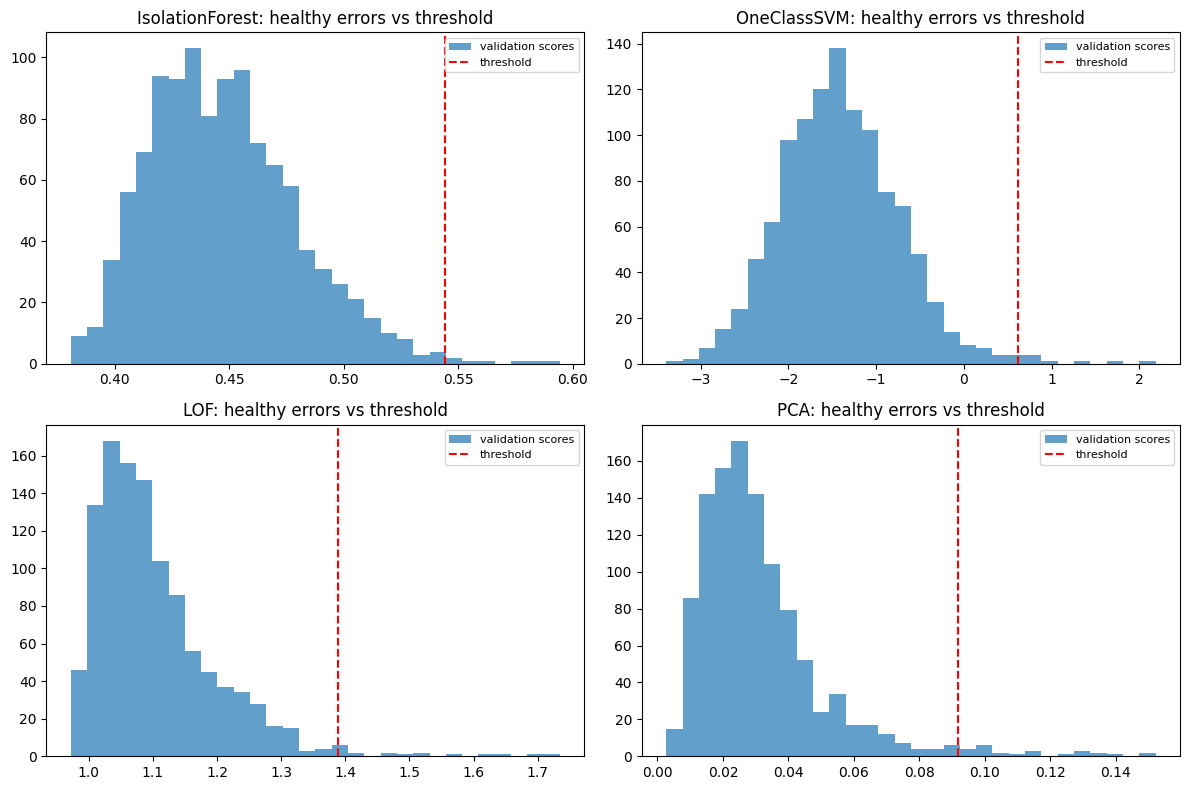

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.flat, ['IsolationForest', 'OneClassSVM', 'LOF', 'PCA']):
    r = classical_results[name]
    ax.hist(r['val_scores'], bins=30, alpha=0.7, label='validation scores')
    ax.axvline(r['threshold'], color='red', linestyle='--', label='threshold')
    ax.set_title(f"{name}: healthy errors vs threshold")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

How to read these plots: each bar counts healthy validation samples by model
score (x = score, y = count). The red line is the threshold. Everything left
of it is quiet, everything right would alarm. The gap between the bulk and
the line is the safety margin: healthy almost never crosses (low FPR), while
fault scores reach far beyond it.

### Per feature breakdown, with startup

Same four models trained on one feature type at a time across all bearings.
Shows which feature carries the fault signal on its own.

In [5]:
from src.experiments import compare_column_setups

types9 = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
          'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
groups = {f: [c for c in df.columns if c.endswith('_' + f)] for f in types9}
train_end = df_healthy_train.index[-1]
val_end = df_healthy.index[-1]
feat_full_df = compare_column_setups(classical, groups, df, df_healthy_train, df_healthy_val,
                                     train_end, val_end, verbose=True)
feat_full_df = feat_full_df.rename(columns={'setup': 'feature'})
print("First confirmed alarm per feature and model, with startup:")
display(feat_full_df.pivot_table(index='feature', columns='model', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per feature and model, with startup:")
display(feat_full_df.pivot_table(index='feature', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))

--- RMS ---


--- Kurtosis ---


--- CrestFactor ---


--- Peak ---


--- Skewness ---


...

--- SpecPeak ---


First confirmed alarm per feature and model, with startup:


model,IsolationForest,LOF,OneClassSVM,PCA
feature,,,,
CrestFactor,NaN,2004-04-18 01:52:55,NaN,NaN
HighFreqRatio,2004-04-15 23:52:55,2004-04-15 17:12:55,2004-04-15 18:32:55,2004-03-04 14:32:46
Kurtosis,2004-03-04 15:32:46,2004-04-17 02:32:55,2004-04-17 02:42:55,2004-04-17 02:32:55
Peak,2004-04-17 02:42:55,2004-04-17 02:42:55,2004-04-17 02:42:55,2004-04-17 12:42:55
RMS,2004-03-04 13:52:46,2004-04-15 18:22:55,2004-04-15 18:22:55,2004-03-04 12:32:46
Skewness,2004-04-17 02:52:55,2004-04-17 02:22:55,2004-04-17 02:22:55,2004-04-17 02:32:55
SpecCentroid,2004-04-17 01:42:55,2004-04-16 23:22:55,2004-04-16 23:32:55,2004-04-17 19:02:55
SpecPeak,NaN,2004-04-16 13:42:55,2004-04-16 22:42:55,NaN
Std,2004-03-04 12:32:46,2004-04-15 18:32:55,2004-04-15 18:22:55,2004-03-04 12:32:46


Validation FPR per feature and model, with startup:


model,IsolationForest,LOF,OneClassSVM,PCA
feature,,,,
CrestFactor,0.0091,0.0173,0.0100,0.0155
HighFreqRatio,0.0100,0.0228,0.0155,0.0191
Kurtosis,0.0155,0.0182,0.0100,0.0109
Peak,0.0082,0.0210,0.0164,0.0164
RMS,0.0027,0.0173,0.0109,0.0055
Skewness,0.0064,0.0228,0.0119,0.0237
SpecCentroid,0.0164,0.0191,0.0109,0.0128
SpecPeak,0.0255,0.0191,0.0027,0.0173
Std,0.0036,0.0228,0.0128,0.0146


Why two FPR numbers: FPR on the train part alone overestimates quality,
it measures how well the model recognizes data it already saw during fitting
rather than how well it generalizes. fpr_val is the reported metric.

## 9. Without startup: joint and per feature

Healthy without the first 50 startup rows, same procedure otherwise.
Tests whether dropping the startup transient fixes IsolationForest and how
each feature behaves per model without startup noise.

In [6]:
h_ns = df[(df.index >= df.index[50]) & (df.index < HEALTHY_BOUNDARY)]
tr_ns, va_ns = split_train_val(h_ns, val_fraction=0.2)
Xtr_ns, Xa_ns, sc_ns = scale_features(tr_ns, df)
Xva_ns = sc_ns.transform(va_ns)
te_ns, ve_ns = tr_ns.index[-1], h_ns.index[-1]
print(f"Healthy without startup: {len(h_ns)} (train {len(tr_ns)}, val {len(va_ns)})")

from src.experiments import run_classical_suite

def _run_models(Xtr_, Xa_, Xva_):
    _, res_ = run_classical_suite(classical, Xtr_, Xa_, Xva_, df.index, te_ns, ve_ns)
    out = {}
    for name, r in res_.items():
        out[name] = ((r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                     round(r['fpr_val'], 4))
    return out

print("Joint without startup (alarm, fpr_val):")
joint_ns = _run_models(Xtr_ns, Xa_ns, Xva_ns)
display(pd.DataFrame(joint_ns, index=['alarm', 'fpr_val']).T)

feat_ns_rows = []
types9 = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
          'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
for feat in types9:
    print(f"--- {feat} ---", flush=True)
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    s_tr, s_xa, s_sc = scale_features(tr_ns[cols], df[cols])
    s_va = s_sc.transform(va_ns[cols])
    res = _run_models(s_tr, s_xa, s_va)
    for name, (alarm, fpr) in res.items():
        feat_ns_rows.append({'feature': feat, 'model': name, 'alarm': alarm, 'fpr': fpr})
feat_ns_df = pd.DataFrame(feat_ns_rows)
print("First confirmed alarm per feature and model, no startup:")
display(feat_ns_df.pivot_table(index='feature', columns='model', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per feature and model, no startup:")
display(feat_ns_df.pivot_table(index='feature', columns='model', values='fpr', aggfunc='first', observed=True).style.format('{:.4f}'))

Healthy without startup: 5435 (train 4348, val 1087)
Joint without startup (alarm, fpr_val):


,alarm,fpr_val
IsolationForest,2004-03-04 15:32:46,0.0046
OneClassSVM,2004-04-15 18:32:55,0.0083
LOF,2004-04-15 18:32:55,0.0138
PCA,2004-04-15 18:32:55,0.0221


--- RMS ---


--- Kurtosis ---


--- CrestFactor ---


...

--- SpecPeak ---


First confirmed alarm per feature and model, no startup:


model,IsolationForest,LOF,OneClassSVM,PCA
feature,,,,
HighFreqRatio,2004-03-04 15:42:46,2004-04-15 17:12:55,2004-04-15 18:32:55,2004-04-16 10:42:55
Kurtosis,2004-03-04 12:32:46,2004-04-17 02:32:55,2004-04-17 02:42:55,2004-04-17 02:32:55
Peak,2004-04-17 02:42:55,2004-04-17 02:42:55,2004-04-17 02:42:55,2004-04-18 02:22:55
RMS,2004-03-04 12:32:46,2004-04-15 18:22:55,2004-04-15 18:22:55,2004-03-04 12:32:46
Skewness,2004-04-17 02:52:55,2004-04-17 02:22:55,2004-04-17 02:22:55,2004-04-17 04:12:55
SpecCentroid,2004-03-04 15:42:46,2004-04-16 23:22:55,2004-04-16 23:32:55,2004-03-04 13:52:46
SpecPeak,NaN,2004-04-16 13:42:55,2004-04-16 22:42:55,NaN
Std,2004-03-04 12:32:46,2004-04-15 18:22:55,2004-04-15 18:22:55,2004-04-15 18:32:55


Validation FPR per feature and model, no startup:


model,IsolationForest,LOF,OneClassSVM,PCA
feature,,,,
CrestFactor,0.0064,0.0166,0.0092,0.0212
HighFreqRatio,0.0101,0.0239,0.0166,0.0184
Kurtosis,0.0166,0.0175,0.0110,0.0110
Peak,0.0101,0.0184,0.0129,0.0239
RMS,0.0028,0.0202,0.0202,0.0110
Skewness,0.0074,0.0239,0.0129,0.0129
SpecCentroid,0.0110,0.0175,0.0083,0.0156
SpecPeak,0.0230,0.0184,0.0018,0.0175
Std,0.0018,0.0239,0.0156,0.0147


## 10. Deep models

Same procedure as classical: train on the healthy train part only, threshold on
validation errors, alarm and FPR on the full timeline. Three dense architectures
(3 runs each) plus one LSTM pilot run. Epochs set to 30 everywhere: the 2nd test learning
curves showed training plateaus around epoch 20.

In [4]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import numpy as np
from src.deep_models import (
    build_autoencoder, run_multiple, reconstruction_error,
)
from src.evaluation import compute_threshold, first_confirmed_alarm

deep_results_3rd = {}
architectures = {
    'AE_1layer': [8],
    'AE_2layer': [12, 6],
    'AE_3layer': [16, 8, 4],
}
for name, hidden_layers in architectures.items():
    print(f"Training {name} (3 runs, 30 epochs)...", flush=True)
    build_fn = lambda hl=hidden_layers: build_autoencoder(input_dim, hl)
    mean_full, _ = run_multiple(build_fn, X_healthy_train, X_all,
                                error_fn=reconstruction_error,
                                n_runs=3, epochs=30, batch_size=32)
    mean_val, _ = run_multiple(build_fn, X_healthy_train, X_healthy_val,
                               error_fn=reconstruction_error,
                               n_runs=3, epochs=30, batch_size=32)
    val_mean = float(np.mean(mean_val))
    val_std = float(np.std(mean_val))
    print(f"{name}: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
    scores_series = pd.Series(mean_full, index=df.index)
    threshold = compute_threshold(mean_val, method="mean_std", n_std=3.0)
    print(f"{name}: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[df.index <= train_end].mean())
    fpr_val = float(is_anomaly[(df.index > train_end) & (df.index <= val_end)].mean())
    print(f"{name}: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
    print()
    deep_results_3rd[name] = {"scores": scores_series, "threshold": float(threshold),
                              "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

Training AE_1layer (3 runs, 30 epochs)...


AE_1layer: val_errors mean=0.00860  std=0.00366
AE_1layer: threshold = 0.00860 + 3*0.00366 = 0.01956
AE_1layer: first_alarm=2004-04-15 18:32:55  fpr_train=0.0148  fpr_val=0.0182 (primary)

Training AE_2layer (3 runs, 30 epochs)...


AE_2layer: val_errors mean=0.00690  std=0.00352
AE_2layer: threshold = 0.00690 + 3*0.00352 = 0.01745
AE_2layer: first_alarm=2004-04-15 18:32:55  fpr_train=0.0121  fpr_val=0.0182 (primary)

Training AE_3layer (3 runs, 30 epochs)...


AE_3layer: val_errors mean=0.01065  std=0.00503
AE_3layer: threshold = 0.01065 + 3*0.00503 = 0.02575
AE_3layer: first_alarm=2004-04-15 18:22:55  fpr_train=0.0103  fpr_val=0.0137 (primary)



In [5]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
import tensorflow as tf
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)
import numpy as np
from src.deep_models import build_lstm_autoencoder, make_windows, run_multiple, reconstruction_error_lstm
from src.evaluation import compute_threshold, first_confirmed_alarm

WINDOW_SIZE = 10
print("Building LSTM windows...", flush=True)
X_healthy_windows = make_windows(X_healthy_train, WINDOW_SIZE)
X_all_windows = make_windows(X_all, WINDOW_SIZE)
X_val_windows = make_windows(X_healthy_val, WINDOW_SIZE)
lstm_index = df.index[WINDOW_SIZE - 1:]
print(f"Training LSTM_AE (3 runs, 30 epochs)...", flush=True)
build_lstm_fn = lambda: build_lstm_autoencoder(WINDOW_SIZE, input_dim, encoding_dim=8)
lstm_full, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_all_windows,
                            error_fn=reconstruction_error_lstm,
                           method="median",
                            n_runs=3, epochs=30, batch_size=32)
lstm_val, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_val_windows,
                           error_fn=reconstruction_error_lstm,
                           method="median",
                           n_runs=3, epochs=30, batch_size=32)
val_mean = float(np.mean(lstm_val))
val_std = float(np.std(lstm_val))
print(f"LSTM_AE: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
lstm_series = pd.Series(lstm_full, index=lstm_index)
threshold = compute_threshold(lstm_val, method="mean_std", n_std=3.0)
print(f"LSTM_AE: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = lstm_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=20)
lstm_train_end = df_healthy_train.index[-1]
fpr_train = float(is_anomaly[(lstm_index <= lstm_train_end)].mean())
fpr_val = float(is_anomaly[(lstm_index > lstm_train_end) & (lstm_index <= df_healthy.index[-1])].mean())
print(f"LSTM_AE: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
try:
    deep_results_3rd
except NameError:
    deep_results_3rd = {}
deep_results_3rd['LSTM_AE'] = {"scores": lstm_series, "threshold": float(threshold),
                               "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

Building LSTM windows...


Training LSTM_AE (3 runs, 30 epochs)...


LSTM_AE: val_errors mean=0.01024  std=0.00159
LSTM_AE: threshold = 0.01024 + 3*0.00159 = 0.01500
LSTM_AE: first_alarm=2004-04-15 17:52:55  fpr_train=0.0126  fpr_val=0.0091 (primary)


Single-seed LSTM alarms flipped between 21.03 and 12.04 on identical code.
Mean over 3 runs still flipped (15.04 vs 03-04), even with deterministic flags.
Median over 3 runs gives 15.04 17:52 on two separate full executions (six trainings total), bit-identical numbers both times once deterministic flags were moved before the first TensorFlow import (they silently did nothing when placed after it). Median is reported;
single seeds and means are not reproducible here.

## 11. CNN on spectrograms (setup)

One frame is one spectrogram image from one raw file (one second of vibration).
6,324 files give 6,324 frames of Bearing 3 at 64x64.
Frames use global normalization: everything is divided by the loudest healthy
frame (0.0516), so healthy frames land at 1.0 or below. The loudest fault frame
reaches 11.3, about 11 times louder than the loudest healthy frame. The network
with sigmoid output reconstructs only up to 1, so fault frames produce large
errors. That error is the alarm signal.
Training cell follows after pilot approval.

Scope note: spectrogram frames come from Bearing 3 alone, because one frame
is one bearing. Everything else in this notebook (joint models, per feature
models) sees all 4 bearings together.

In [4]:
import numpy as np
from src.spectro import load_spectrograms, cache_path
from src.deep_models import build_cnn_autoencoder, run_multiple, reconstruction_error_images
from src.evaluation import compute_threshold, first_confirmed_alarm

X_spec, idx_spec = load_spectrograms(cache_path('data/raw/3rd_test/', 'Bearing_3', norm='global'))
X_spec = X_spec[..., None]
h_pos = np.flatnonzero(idx_spec < HEALTHY_BOUNDARY)
n_spec_val = int(len(h_pos) * 0.2)
train_pos, val_pos = h_pos[:-n_spec_val], h_pos[-n_spec_val:]
Xtr_spec, Xva_spec = X_spec[train_pos], X_spec[val_pos]
print(f"Spectrogram frames - train: {len(Xtr_spec)}, val: {len(Xva_spec)}, all: {len(X_spec)}", flush=True)

print("Training CNN pilot (3 runs, 30 epochs)...", flush=True)
build_cnn_fn = lambda: build_cnn_autoencoder(64, 64)
cnn_full, _ = run_multiple(build_cnn_fn, Xtr_spec, X_spec,
                            error_fn=reconstruction_error_images,
                            n_runs=3, epochs=30, batch_size=32)
cnn_val, _ = run_multiple(build_cnn_fn, Xtr_spec, Xva_spec,
                           error_fn=reconstruction_error_images,
                           n_runs=3, epochs=30, batch_size=32)
val_mean = float(np.mean(cnn_val))
val_std = float(np.std(cnn_val))
print(f"CNN: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
cnn_series = pd.Series(cnn_full, index=idx_spec)
threshold = compute_threshold(cnn_val, method="mean_std", n_std=3.0)
print(f"CNN: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = cnn_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=20)
fpr_train = float(is_anomaly.iloc[train_pos].mean())
fpr_val = float(is_anomaly.iloc[val_pos].mean())
print(f"CNN: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")

Spectrogram frames - train: 4388, val: 1097, all: 6324


Training CNN pilot (3 runs, 30 epochs)...


CNN: val_errors mean=0.00107  std=0.00005
CNN: threshold = 0.00107 + 3*0.00005 = 0.00122
CNN: first_alarm=2004-04-15 18:32:55  fpr_train=0.0018  fpr_val=0.0000 (primary)


Single run gave alarm 15.04 18:12 with FPR 0.0027/0.0027. Three run average
gives alarm 15.04 18:32 with FPR 0.0018/0.0000: 20 minutes later, but cleaner.
Single seeds wobble, the average is reported.

## Epoch unification note (25 to 30)

Old alarms (25 epochs): AE_1/2 on 15.04 18:32, AE_3 on 15.04 18:22,
LSTM median on 15.04 17:52. New alarms (30 epochs): identical.

| model | threshold 25ep | threshold 30ep | fpr_val 25ep | fpr_val 30ep |
|---|---|---|---|---|
| AE_1layer | 0.01966 | 0.01956 | 0.0128 | 0.0182 |
| AE_2layer | 0.01813 | 0.01745 | 0.0182 | 0.0182 |
| AE_3layer | 0.02592 | 0.02575 | 0.0146 | 0.0137 |
| LSTM_AE | 0.01585 | 0.01500 | 0.0119 | 0.0091 |

Thresholds and FPRs wobble slightly, alarms stand. Epoch count does not
move alarms on this test.